In [1]:
# %pip install albumentations opencv-python pandas matplotlib scikit-learn

In [2]:
import os
import gc
import cv2
import json
import yaml
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations as A
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score
import segmentation_models_pytorch as smp


c:\Users\Latko Artem\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


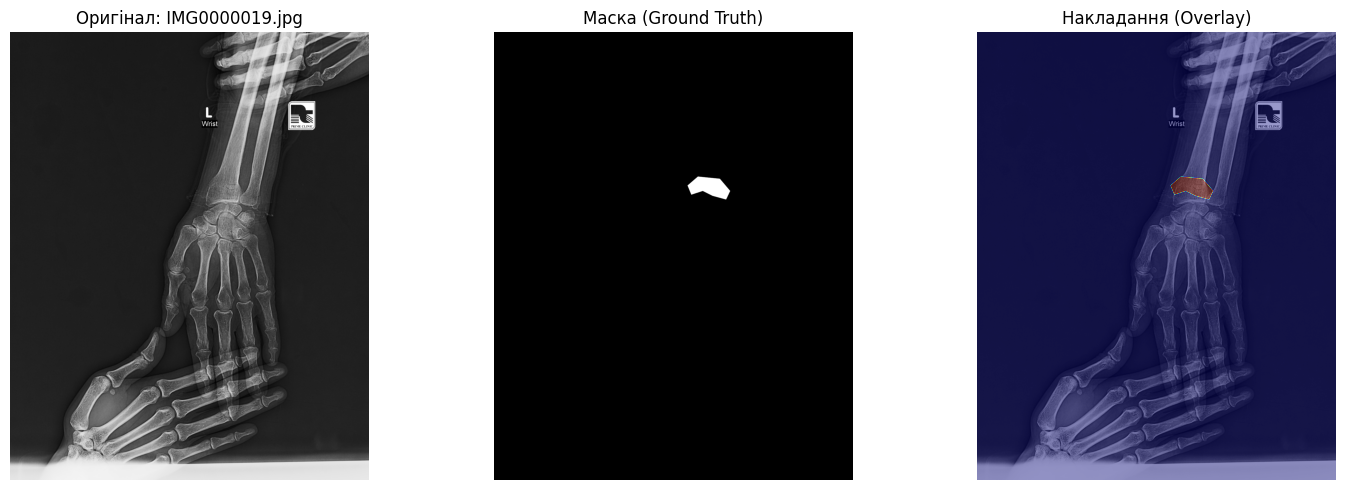

In [3]:
# 1. Вказуємо шляхи до папок
image_dir = '../../multitask-bone-fracture-ai/data/FracAtlas/images/Fractured'

# Увага: перевірте точну назву json-файлу у вашій папці "VGG JSON"
# Він може називатися "VGG_fracture_masks.json", "dataset.json" або подібно
vgg_json_path = '../../multitask-bone-fracture-ai/data/FracAtlas/Annotations/VGG JSON/VGG_fracture_masks.json'

# 2. Відкриваємо файл з координатами масок
with open(vgg_json_path, 'r') as f:
    vgg_data = json.load(f)

# 3. Вибираємо перше-ліпше зображення з JSON
image_key = list(vgg_data.keys())[0]
image_info = vgg_data[image_key]
image_name = image_info['filename']

# 4. Завантажуємо оригінальний рентген
img_path = os.path.join(image_dir, image_name)
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV читає в BGR, переводимо в RGB для Matplotlib

# 5. Створюємо порожню (чорну) маску такого ж розміру, як рентген
mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

# 6. Малюємо полігони (переломи) на нашій чорній масці
regions = image_info.get('regions', [])
# VGG JSON може зберігати регіони як словник або список, обробляємо обидва варіанти
if isinstance(regions, dict):
    regions = list(regions.values())

for region in regions:
    shape = region.get('shape_attributes', {})
    if shape.get('name') == 'polygon':
        # Дістаємо X та Y координати багатокутника
        points_x = shape['all_points_x']
        points_y = shape['all_points_y']

        # Об'єднуємо їх у формат для OpenCV: [[[x1, y1], [x2, y2], ...]]
        polygon_points = np.column_stack((points_x, points_y)).astype(np.int32)

        # Замальовуємо цей багатокутник білим кольором (255)
        cv2.fillPoly(mask, [polygon_points], color=255)

# 7. Будуємо красиву візуалізацію
plt.figure(figsize=(15, 5))

# Оригінальний знімок
plt.subplot(1, 3, 1)
plt.title(f"Оригінал: {image_name}")
plt.imshow(img_rgb)
plt.axis('off')

# Згенерована маска
plt.subplot(1, 3, 2)
plt.title("Маска (Ground Truth)")
plt.imshow(mask, cmap='gray')
plt.axis('off')

# Накладання маски на рентген (Overlay)
plt.subplot(1, 3, 3)
plt.title("Накладання (Overlay)")
plt.imshow(img_rgb)
# Накладаємо маску поверх оригінального знімку (відобразиться як теплова карта)
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 1. Налаштування шляхів з використанням pathlib для зручності
base_dir = Path('../../multitask-bone-fracture-ai/data/FracAtlas')
images_fractured_dir = base_dir / 'images' / 'Fractured'
images_non_fractured_dir = base_dir / 'images' / 'Non_fractured'
vgg_json_path = base_dir / 'Annotations' / 'VGG JSON' / 'VGG_fracture_masks.json'

# Створюємо цільову папку для всіх масок
masks_save_dir = base_dir / 'masks'
masks_save_dir.mkdir(parents=True, exist_ok=True)

# 2. Обробка зображень З ПЕРЕЛОМАМИ (за даними JSON)
print("Генерація масок для знімків з переломами...")
with open(vgg_json_path, 'r') as f:
    vgg_data = json.load(f)

for image_key, image_info in tqdm(vgg_data.items()):
    image_name = image_info['filename']
    img_path = images_fractured_dir / image_name

    # Перевіряємо, чи існує файл фізично
    if not img_path.exists():
        continue

    # Читаємо зображення, щоб дізнатися його оригінальний розмір
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    regions = image_info.get('regions', [])
    if isinstance(regions, dict):
        regions = list(regions.values())

    for region in regions:
        shape = region.get('shape_attributes', {})
        if shape.get('name') == 'polygon':
            points_x = shape['all_points_x']
            points_y = shape['all_points_y']

            # Об'єднуємо координати та малюємо багатокутник
            polygon_points = np.column_stack((points_x, points_y)).astype(np.int32)
            cv2.fillPoly(mask, [polygon_points], color=255)

    # Зберігаємо маску у форматі PNG (важливо для збереження чітких меж 0 і 255)
    mask_filename = img_path.stem + '.png'
    cv2.imwrite(str(masks_save_dir / mask_filename), mask)

# 3. Обробка зображень БЕЗ ПЕРЕЛОМІВ (створення порожніх масок)
print("\nГенерація порожніх масок для здорових знімків...")
# Шукаємо всі файли в папці здорових знімків
non_fractured_images = list(images_non_fractured_dir.glob('*.*'))

for img_path in tqdm(non_fractured_images):
    # Фільтруємо випадкові системні файли
    if img_path.suffix.lower() not in ['.jpg', '.png', '.jpeg']:
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]

    # Для здорових кісток маска повністю чорна (0)
    blank_mask = np.zeros((h, w), dtype=np.uint8)

    mask_filename = img_path.stem + '.png'
    cv2.imwrite(str(masks_save_dir / mask_filename), blank_mask)

print(f"\nГотово! Всі маски (як із переломами, так і порожні) успішно збережені у папку: {masks_save_dir}")

Генерація масок для знімків з переломами...


  0%|          | 0/717 [00:00<?, ?it/s]

100%|██████████| 717/717 [00:07<00:00, 98.21it/s] 



Генерація порожніх масок для здорових знімків...


100%|██████████| 3366/3366 [00:22<00:00, 148.11it/s]


Готово! Всі маски (як із переломами, так і порожні) успішно збережені у папку: ..\..\multitask-bone-fracture-ai\data\FracAtlas\masks


In [5]:
class FracAtlasDataset(Dataset):
    """
    Кастомний Dataset для датасету FracAtlas.
    Зчитує image_id зі спліту (train/valid/test) та підтягує мітки з головного dataset.csv.
    """
    def __init__(self, split_csv, dataset_csv, img_dir, mask_dir, transform=None):
        """
        :param split_csv: Шлях до файлу спліту (наприклад, 'train.csv')
        :param dataset_csv: Шлях до загального файлу 'dataset.csv' з усіма мітками
        :param img_dir: Шлях до папки з оригінальними картинками (Fractured + Non_fractured)
        :param mask_dir: Шлях до папки зі згенерованими масками
        :param transform: Об'єкт аугментації (Albumentations)
        """
        # Завантажуємо спліт (тільки імена файлів)
        split_df = pd.read_csv(split_csv)
        # Завантажуємо всі анотації
        full_df = pd.read_csv(dataset_csv)

        # Фільтруємо анотації: залишаємо тільки ті рядки, image_id яких є у нашому спліті
        self.data_frame = full_df[full_df['image_id'].isin(split_df['image_id'])].reset_index(drop=True)

        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Колонки, що відповідають за тип кістки (Multi-label)
        self.bone_classes = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]
        img_name = str(row['image_id'])

        # 1. Мітки типу кістки (Отримуємо масив з 5 значень: [0, 1, 0, 0, 0])
        bone_labels = row[self.bone_classes].values.astype(np.float32)
        bone_tensor = torch.tensor(bone_labels, dtype=torch.float32)

        # 2. Мітка перелому (Одне значення: 0.0 або 1.0)
        fracture_label = float(row['fractured'])
        fracture_tensor = torch.tensor(fracture_label, dtype=torch.float32).unsqueeze(0)

        # 3. Шляхи до файлів
        # Враховуємо, що зображення можуть лежати у двох різних папках
        path_fractured = os.path.join(self.img_dir, 'Fractured', img_name)
        path_non_fractured = os.path.join(self.img_dir, 'Non_fractured', img_name)

        if os.path.exists(path_fractured):
            img_path = path_fractured
        elif os.path.exists(path_non_fractured):
            img_path = path_non_fractured
        else:
            raise FileNotFoundError(f"Зображення {img_name} не знайдено в папках Fractured/Non_fractured")

        # Маски ми зберігали всі в одну папку 'masks' у форматі PNG
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 4. Завантаження картинки
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Помилка читання файлу: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 5. Завантаження маски
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.float32) # Бінаризація (0 та 1)
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

        # 6. Аугментація (спільна для картинки та маски)
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

            # Albumentations повертає маску розмірності (H, W), додаємо канал -> (1, H, W)
            mask = mask.unsqueeze(0)

        return image, bone_tensor, fracture_tensor, mask

# Функції аугментації для тренування та валідації
def get_train_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_segmenter_transforms():
    """
    Трансформації для U-Net (512x512).
    ElasticTransform — деформація кістки/лінії перелому.
    CLAHE           — локальне підсилення контрасту рентгену.
    GaussNoise      — симуляція шуму сенсора.
    """
    return A.Compose([
        A.Resize(512, 512),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(p=0.3),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.05, 0.05),
            rotate=(-20, 20),
            p=0.5
        ),
        A.ElasticTransform(alpha=120, sigma=6, p=0.3),
        A.CLAHE(clip_limit=4.0, p=0.3),
        A.GaussNoise(std_range=(0.02, 0.08), p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_valid_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_segmenter_valid_transforms():
    return A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

In [6]:
# Вказуємо правильні шляхи до твоїх файлів
split_csv_path = '../data/FracAtlas/Utilities/Fracture Split/train.csv'
dataset_csv_path = '../data/FracAtlas/dataset.csv'
img_dir_path = '../data/FracAtlas/images'
mask_dir_path = '../data/FracAtlas/masks'

# Ініціалізуємо наш датасет
train_dataset = FracAtlasDataset(
    split_csv=split_csv_path,
    dataset_csv=dataset_csv_path,
    img_dir=img_dir_path,
    mask_dir=mask_dir_path,
    transform=get_train_transforms()
)

# Створюємо DataLoader (беремо 4 картинки за раз)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Беремо один тестовий батч
images, bone_labels, fracture_labels, masks = next(iter(train_loader))

# Виводимо розмірності тензорів
print(f"Тензор зображень: {images.shape}")
print(f"Тензор типу кісток (Multi-label): {bone_labels.shape}")
print(f"Тензор наявності перелому: {fracture_labels.shape}")
print(f"Тензор масок сегментації: {masks.shape}")

C:\Users\Latko Artem\AppData\Roaming\Python\Python312\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Тензор зображень: torch.Size([4, 3, 224, 224])
Тензор типу кісток (Multi-label): torch.Size([4, 5])
Тензор наявності перелому: torch.Size([4, 1])
Тензор масок сегментації: torch.Size([4, 1, 224, 224])


In [7]:
# ==========================================
# 1. МУЛЬТИЗАДАЧНИЙ КЛАСИФІКАТОР (Етап скринінгу)
# ==========================================
class MultiTaskClassifier(nn.Module):
    """
    Мультизадачна модель на базі ResNet50 для одночасного
    визначення типу кістки та наявності перелому.
    """
    def __init__(self, num_bone_classes=5):
        super(MultiTaskClassifier, self).__init__()

        # Завантажуємо попередньо навчену ResNet50 (Transfer Learning)
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # Відрізаємо останній шар (fc), залишаючи лише екстрактор ознак
        # Це відповідає формулі: f = backbone(x), де f ∈ R^2048
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        in_features = resnet.fc.in_features # 2048

        # Task-specific гілки (Heads)
        self.bone_head = nn.Linear(in_features, num_bone_classes)
        self.fracture_head = nn.Linear(in_features, 1)

    def forward(self, x):
        # 1. Витягуємо ознаки (Feature extraction)
        f = self.backbone(x)
        f = torch.flatten(f, 1) # Згладжуємо тензор [B, 2048, 1, 1] у [B, 2048]

        # 2. Пропускаємо через голови
        logits_bone = self.bone_head(f)
        logits_fracture = self.fracture_head(f)

        return logits_bone, logits_fracture


# ==========================================
# 2. СЕГМЕНТАЦІЙНА МОДЕЛЬ U-NET (Етап деталізації)
# ==========================================
class FractureSegmenter(nn.Module):
    """
    U-Net з pretrained ResNet50 encoder (ImageNet weights).
    Зберігає той самий інтерфейс, що й попередній scratch U-Net:
    FractureSegmenter(in_channels=3, out_channels=1)
    """
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.model = smp.Unet(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,
            activation=None,  # повертає логіти — сигмоїда у FocalTverskyLoss
        )

    def forward(self, x):
        return self.model(x)

In [8]:
# ==========================================
# 1. ФУНКЦІЇ ВТРАТ (Loss Functions)
# ==========================================

class MultiTaskLoss(nn.Module):
    """
    Зважена сума функцій втрат для мультизадачного класифікатора.
    L_total = lambda1 * L_bone + lambda2 * L_fracture
    """
    def __init__(self, lambda_bone=1.0, lambda_fracture=2.0):
        super().__init__()
        self.lambda_bone = lambda_bone
        self.lambda_fracture = lambda_fracture
        # Використовуємо BCEWithLogitsLoss для обох задач,
        # оскільки тип кістки - це Multi-label, а перелом - бінарна класифікація
        self.bce_bone = nn.BCEWithLogitsLoss()
        self.bce_fracture = nn.BCEWithLogitsLoss()

    def forward(self, logits_bone, targets_bone, logits_fracture, targets_fracture):
        loss_bone = self.bce_bone(logits_bone, targets_bone)
        loss_fracture = self.bce_fracture(logits_fracture, targets_fracture)
        return (self.lambda_bone * loss_bone) + (self.lambda_fracture * loss_fracture)


class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky Loss для сегментації з класовим дисбалансом.
    Переломи займають малу частку пікселів, тому alpha > beta:
    пропущені переломи (FN) штрафуються сильніше, ніж хибні спрацювання (FP).

    alpha: вага FN  (рекомендовано 0.7)
    beta:  вага FP  (рекомендовано 0.3)
    gamma: focal параметр, фокус на важких прикладах (рекомендовано 0.75)
    """
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits_mask, targets_mask):
        probs = torch.sigmoid(logits_mask)

        # Підраховуємо TP, FP, FN окремо для кожного семплу
        tp = (probs * targets_mask).sum(dim=(1, 2, 3))
        fp = (probs * (1.0 - targets_mask)).sum(dim=(1, 2, 3))
        fn = ((1.0 - probs) * targets_mask).sum(dim=(1, 2, 3))

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fn + self.beta * fp + self.smooth
        )
        # Focal параметр gamma зменшує loss для легких прикладів
        focal_tversky = (1.0 - tversky) ** self.gamma
        return focal_tversky.mean()

# Зворотна сумісність: старе ім'я вказує на новий клас
DiceBCELoss = FocalTverskyLoss


# ==========================================
# 2. ЦИКЛ НАВЧАННЯ (Trainer)
# ==========================================

def train_classifier_epoch(model, dataloader, criterion, optimizer, device):
    """
    Тренування мультизадачного класифікатора протягом однієї епохи з підрахунком метрик.
    """
    model.train()
    running_loss = 0.0

    # Списки для накопичення результатів по всій епосі
    all_frac_preds, all_frac_targets = [], []
    all_bone_preds, all_bone_targets = [], []

    pbar = tqdm(dataloader, desc="Training Classifier", leave=False)

    for batch in pbar:
        images, bone_labels, fracture_labels, _ = batch

        images = images.to(device)
        bone_labels = bone_labels.to(device)
        fracture_labels = fracture_labels.to(device)

        optimizer.zero_grad()
        logits_bone, logits_fracture = model(images)
        loss = criterion(logits_bone, bone_labels, logits_fracture, fracture_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # --- ЗБІР ДАНИХ ДЛЯ МЕТРИК ---
        # Пропускаємо логіти через сигмоїду і застосовуємо поріг 0.5
        with torch.no_grad():
            # 1. Для переломів
            frac_preds = (torch.sigmoid(logits_fracture) > 0.5).cpu().numpy()
            all_frac_preds.extend(frac_preds)
            all_frac_targets.extend(fracture_labels.cpu().numpy())

            # 2. Для типу кістки
            bone_preds = (torch.sigmoid(logits_bone) > 0.5).cpu().numpy()
            all_bone_preds.extend(bone_preds)
            all_bone_targets.extend(bone_labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(dataloader)

    # --- РОЗРАХУНОК МЕТРИК ---
    # zero_division=0 уникає помилок на перших епохах, коли модель може видавати суцільні нулі
    metrics = {
        'loss': epoch_loss,
        'frac_recall': recall_score(all_frac_targets, all_frac_preds, zero_division=0),
        'frac_f1': f1_score(all_frac_targets, all_frac_preds, zero_division=0),
        'frac_acc': accuracy_score(all_frac_targets, all_frac_preds),
        # Використовуємо average='macro' для Multi-label класифікації кісток
        'bone_f1': f1_score(all_bone_targets, all_bone_preds, average='macro', zero_division=0)
    }

    return metrics

# ==========================================
# 3. ЦИКЛ ВАЛІДАЦІЇ КЛАСИФІКАТОРА  ← НОВА ФУНКЦІЯ
# ==========================================

def eval_classifier_epoch(model, dataloader, criterion, device):
    """
    Валідація мультизадачного класифікатора (без оновлення градієнтів).
    Повертає той самий словник метрик, що й train_classifier_epoch.
    """
    model.eval()  # ← переводить BatchNorm/Dropout у режим інференсу
    running_loss = 0.0

    all_frac_preds, all_frac_targets = [], []
    all_bone_preds, all_bone_targets = [], []

    pbar = tqdm(dataloader, desc="Validating Classifier", leave=False)

    with torch.no_grad():  # ← вимикаємо автодиференціювання
        for batch in pbar:
            images, bone_labels, fracture_labels, _ = batch

            images = images.to(device)
            bone_labels = bone_labels.to(device)
            fracture_labels = fracture_labels.to(device)

            logits_bone, logits_fracture = model(images)
            loss = criterion(logits_bone, bone_labels, logits_fracture, fracture_labels)
            running_loss += loss.item()

            frac_preds = (torch.sigmoid(logits_fracture) > 0.5).cpu().numpy()
            all_frac_preds.extend(frac_preds)
            all_frac_targets.extend(fracture_labels.cpu().numpy())

            bone_preds = (torch.sigmoid(logits_bone) > 0.5).cpu().numpy()
            all_bone_preds.extend(bone_preds)
            all_bone_targets.extend(bone_labels.cpu().numpy())

            pbar.set_postfix({'val_loss': loss.item()})

    epoch_loss = running_loss / len(dataloader)

    metrics = {
        'loss': epoch_loss,
        'frac_recall': recall_score(all_frac_targets, all_frac_preds, zero_division=0),
        'frac_f1': f1_score(all_frac_targets, all_frac_preds, zero_division=0),
        'frac_acc': accuracy_score(all_frac_targets, all_frac_preds),
        'bone_f1': f1_score(all_bone_targets, all_bone_preds, average='macro', zero_division=0)
    }

    return metrics


In [9]:
def train_segmenter_epoch(model, dataloader, criterion, optimizer, device):
    """
    Тренування сегментаційної моделі (U-Net) протягом однієї епохи.
    Навчається лише на знімках, де Є перелом (D_frac).
    """
    model.train()
    running_loss = 0.0

    # Змінні для накопичення метрик
    epoch_dice = 0.0
    epoch_iou = 0.0
    batches_count = 0 # Лічильник батчів, у яких були переломи

    pbar = tqdm(dataloader, desc="Training Segmenter", leave=False)

    for batch in pbar:
        images, _, fracture_labels, masks = batch

        # --- ФІЛЬТРАЦІЯ D_frac ---
        # Знаходимо індекси картинок, де fracture_label == 1.0 (є перелом)
        is_fractured = (fracture_labels.view(-1) == 1.0)

        # Якщо в поточному батчі взагалі немає переломів - пропускаємо його
        if not is_fractured.any():
            continue

        # Залишаємо тільки знімки з переломами та їхні маски
        images = images[is_fractured].to(device)
        masks = masks[is_fractured].to(device)

        # 1. Обнуляємо градієнти
        optimizer.zero_grad()

        # 2. Прямий прохід
        logits_mask = model(images)

        # 3. Рахуємо помилку (Dice + BCE)
        loss = criterion(logits_mask, masks)

        # 4. Зворотне поширення та крок оптимізатора
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # --- РОЗРАХУНОК МЕТРИК DSC та IoU ---
        with torch.no_grad():
            # Переводимо логіти у бінарну маску
            preds = (torch.sigmoid(logits_mask) > 0.5).float()

            # Рахуємо перетин (Intersection) та об'єднання (Union) для кожного знімка в батчі
            # Розмірності: [B, 1, H, W] -> сумуємо по каналах, висоті та ширині (dim=(1,2,3))
            intersection = (preds * masks).sum(dim=(1, 2, 3))
            union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

            # Додаємо smooth (1e-6), щоб уникнути ділення на нуль
            smooth = 1e-6
            iou = (intersection + smooth) / (union + smooth)
            dice = (2. * intersection + smooth) / (preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) + smooth)

            # Додаємо середнє значення по батчу до загальної суми
            epoch_iou += iou.mean().item()
            epoch_dice += dice.mean().item()
            batches_count += 1

        pbar.set_postfix({'loss': loss.item()})

    # Повертаємо усереднені метрики (захист від ділення на 0, якщо переломів не було взагалі)
    if batches_count > 0:
        return {
            'loss': running_loss / batches_count,
            'dice': epoch_dice / batches_count,
            'iou': epoch_iou / batches_count
        }
    else:
        return {'loss': 0, 'dice': 0, 'iou': 0}

# ==========================================
# ЦИКЛ ВАЛІДАЦІЇ СЕГМЕНТАТОРА  ← НОВА ФУНКЦІЯ
# ==========================================

def eval_segmenter_epoch(model, dataloader, device):
    """
    Валідація U-Net. Рахує Dice та IoU лише на знімках з переломами,
    щоб порожні маски не завищували метрики штучно.
    """
    model.eval()
    epoch_dice = 0.0
    epoch_iou = 0.0
    batches_count = 0

    pbar = tqdm(dataloader, desc="Validating Segmenter", leave=False)

    with torch.no_grad():
        for batch in pbar:
            images, _, fracture_labels, masks = batch

            # ← Фільтруємо: лише знімки де є перелом
            is_fractured = (fracture_labels.view(-1) == 1.0)
            if not is_fractured.any():
                continue

            images = images[is_fractured].to(device)
            masks = masks[is_fractured].to(device)

            logits_mask = model(images)
            preds = (torch.sigmoid(logits_mask) > 0.5).float()

            intersection = (preds * masks).sum(dim=(1, 2, 3))
            union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

            smooth = 1e-6
            iou = (intersection + smooth) / (union + smooth)
            dice = (2. * intersection + smooth) / (preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) + smooth)

            epoch_iou += iou.mean().item()
            epoch_dice += dice.mean().item()
            batches_count += 1

    if batches_count > 0:
        return {
            'dice': epoch_dice / batches_count,
            'iou': epoch_iou / batches_count
        }
    else:
        return {'dice': 0.0, 'iou': 0.0}


In [10]:
def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)


# 1. Завантаження конфігурації
config = load_config('../configs/config.yaml')

# Визначення пристрою (GPU чи CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Запуск навчання на: {device}")

# 2. Ініціалізація датасету та DataLoader
print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_train_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['classifier']['batch_size'],
    shuffle=True,
    num_workers=0
)

# ← НОВЕ: завантажуємо валідаційний датасет
print("📦 Завантаження валідаційних даних...")
val_dataset = FracAtlasDataset(
    split_csv=config['data']['valid_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_valid_transforms()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config['classifier']['batch_size'],
    shuffle=False,
    num_workers=0
)

# 3. Ініціалізація моделі (Етап 1: Класифікатор)
print("🧠 Ініціалізація моделі MultiTaskClassifier...")
model = MultiTaskClassifier(num_bone_classes=5).to(device)

# 4. Визначення функції втрат та оптимізатора
# Згідно з математичним описом, використовуємо Adam optimizer
criterion = MultiTaskLoss(lambda_bone=1.0, lambda_fracture=2.0).to(device)
optimizer = optim.Adam(model.parameters(), lr=config['classifier']['learning_rate'])

# 5. Цикл навчання
num_epochs = config['classifier']['num_epochs']
print(f"🔥 Починаємо тренування на {num_epochs} епох...")

for epoch in range(1, num_epochs + 1):
    print(f"\n--- Епоха {epoch}/{num_epochs} ---")

    # Запускаємо нашу функцію з trainer.py (тепер вона повертає словник metrics)
    metrics = train_classifier_epoch(model, train_loader, criterion, optimizer, device)

    # Красивий вивід тренувальних метрик
    print(f"✅ Train Loss: {metrics['loss']:.4f}")
    print(f"   🦴 Bone F1 (Multi-label): {metrics['bone_f1']:.4f}")
    print(f"   ⚡ Fracture Recall:       {metrics['frac_recall']:.4f}")
    print(f"   ⚡ Fracture F1-score:     {metrics['frac_f1']:.4f}")

    # ← НОВЕ: валідаційний прохід після кожної епохи
    val_metrics = eval_classifier_epoch(model, val_loader, criterion, device)
    print(f"   📋 Val Loss: {val_metrics['loss']:.4f} | Val F1-frac: {val_metrics['frac_f1']:.4f} | Val Recall: {val_metrics['frac_recall']:.4f}")

print("\n🎉 Тренування класифікатора завершено!")

# Збереження ваг моделі
torch.save(model.state_dict(), "multitask_classifier.pth")
print("💾 Ваги моделі збережено у файл 'multitask_classifier.pth'")

🚀 Запуск навчання на: cuda
📦 Завантаження даних...
📦 Завантаження валідаційних даних...
🧠 Ініціалізація моделі MultiTaskClassifier...


C:\Users\Latko Artem\AppData\Roaming\Python\Python312\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


🔥 Починаємо тренування на 5 епох...

--- Епоха 1/5 ---


✅ Train Loss: 0.5166
   🦴 Bone F1 (Multi-label): 0.4213
   ⚡ Fracture Recall:       0.9669
   ⚡ Fracture F1-score:     0.9832


   📋 Val Loss: 0.1236 | Val F1-frac: 1.0000 | Val Recall: 1.0000

--- Епоха 2/5 ---


...

   📋 Val Loss: 0.6952 | Val F1-frac: 1.0000 | Val Recall: 1.0000

--- Епоха 4/5 ---


✅ Train Loss: 0.1111
   🦴 Bone F1 (Multi-label): 0.8656
   ⚡ Fracture Recall:       1.0000
   ⚡ Fracture F1-score:     1.0000


   📋 Val Loss: 0.1574 | Val F1-frac: 1.0000 | Val Recall: 1.0000

--- Епоха 5/5 ---


✅ Train Loss: 0.0883
   🦴 Bone F1 (Multi-label): 0.9055
   ⚡ Fracture Recall:       1.0000
   ⚡ Fracture F1-score:     1.0000


   📋 Val Loss: 0.0649 | Val F1-frac: 1.0000 | Val Recall: 1.0000

🎉 Тренування класифікатора завершено!
💾 Ваги моделі збережено у файл 'multitask_classifier.pth'


In [12]:
# Примусове очищення пам'яті перед стартом
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)


# 1. Завантаження конфігурації
config = load_config('../configs/config.yaml')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Запуск навчання сегментатора на: {device}")

# 2. Ініціалізація датасету
print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=0
)

# 3. Ініціалізація моделі (Етап 2: U-Net)
print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# 4. Валідаційний датасет для сегментатора
print("📦 Завантаження валідаційних даних...")
val_dataset_seg = FracAtlasDataset(
    split_csv=config['data']['valid_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_valid_transforms()
)
val_loader_seg = DataLoader(
    val_dataset_seg,
    batch_size=config['segmenter']['batch_size'],
    shuffle=False,
    num_workers=0
)

# 5. Функція втрат, оптимізатор, scheduler
criterion = DiceBCELoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=config['segmenter']['learning_rate'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

# 6. Цикл навчання
num_epochs = config['segmenter']['num_epochs']
print(f"🔥 Починаємо тренування сегментатора на {num_epochs} епох...")

best_val_dice = 0.0
best_checkpoint = "fracture_segmenter_v2_best.pth"

for epoch in range(1, num_epochs + 1):
    print(f"--- Епоха {epoch}/{num_epochs} ---")

    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)
    print(f"✅ Train Loss: {metrics['loss']:.4f} | Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f}")

    val_metrics = eval_segmenter_epoch(model, val_loader_seg, device)
    print(f"   📋 Val   Dice: {val_metrics['dice']:.4f} | IoU: {val_metrics['iou']:.4f}")

    scheduler.step(val_metrics['dice'])

    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), best_checkpoint)
        print(f"   💾 Новий кращий val Dice: {best_val_dice:.4f} — збережено")

print(f"🎉 Тренування U-Net завершено! Кращий val Dice: {best_val_dice:.4f}")

model.load_state_dict(torch.load(best_checkpoint, map_location=device))
torch.save(model.state_dict(), "fracture_segmenter_v2.pth")
print("💾 Ваги збережено у файл 'fracture_segmenter_v2.pth'")

🚀 Запуск навчання сегментатора на: cuda
📦 Завантаження даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...


c:\Users\Latko Artem\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


📦 Завантаження валідаційних даних...
🔥 Починаємо тренування сегментатора на 50 епох...
--- Епоха 1/50 ---


✅ Train Loss: 0.9462 | Dice: 0.0655 | IoU: 0.0357


   📋 Val   Dice: 0.0818 | IoU: 0.0441
   💾 Новий кращий val Dice: 0.0818 — збережено
--- Епоха 2/50 ---


...

✅ Train Loss: 0.6324 | Dice: 0.3957 | IoU: 0.2859


   📋 Val   Dice: 0.3949 | IoU: 0.2900
--- Епоха 50/50 ---


✅ Train Loss: 0.6397 | Dice: 0.3851 | IoU: 0.2751


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\3327923056.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint, map

   📋 Val   Dice: 0.3968 | IoU: 0.2941
   💾 Новий кращий val Dice: 0.3968 — збережено
🎉 Тренування U-Net завершено! Кращий val Dice: 0.3968
💾 Ваги збережено у файл 'fracture_segmenter_v2.pth'


In [13]:
# Очищення пам'яті перед стартом (щоб не було Out of Memory)
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=0
)


# ← НОВЕ: валідаційний датасет для сегментатора
print("📦 Завантаження валідаційних даних...")
val_dataset_seg = FracAtlasDataset(
    split_csv=config['data']['valid_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_valid_transforms()
)
val_loader_seg = DataLoader(
    val_dataset_seg,
    batch_size=config['segmenter']['batch_size'],
    shuffle=False,
    num_workers=0
)

print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# ==========================================================
# НОВА ЧАСТИНА: Завантажуємо знання з попередніх 50 епох!
model.load_state_dict(torch.load("fracture_segmenter_v2.pth", map_location=device))
print("♻️ Попередні ваги (v2) успішно завантажено! Продовжуємо навчання.")
# ==========================================================

criterion = DiceBCELoss().to(device)

# Зменшуємо learning_rate в 5 разів для "тонкого доналаштування" (fine-tuning)
new_lr = 0.0005
optimizer = optim.Adam(model.parameters(), lr=new_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

# Поставимо ще 50 епох
num_epochs = 50
print(f"🔥 Продовжуємо тренування ще на {num_epochs} епох з LR={new_lr}...")

best_val_dice = 0.0
best_checkpoint = "fracture_segmenter_v3_best.pth"

for epoch in range(1, num_epochs + 1):
    print(f"--- Додаткова Епоха {epoch}/{num_epochs} ---")
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)

    print(f"✅ Train Loss: {metrics['loss']:.4f} | Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f}")

    val_metrics = eval_segmenter_epoch(model, val_loader_seg, device)
    print(f"   📋 Val   Dice: {val_metrics['dice']:.4f} | IoU: {val_metrics['iou']:.4f}")

    scheduler.step(val_metrics['dice'])

    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), best_checkpoint)
        print(f"   💾 Новий кращий val Dice: {best_val_dice:.4f} — збережено у '{best_checkpoint}'")

print(f"🎉 Додаткове тренування завершено! Кращий val Dice: {best_val_dice:.4f}")

model.load_state_dict(torch.load(best_checkpoint, map_location=device))
torch.save(model.state_dict(), "fracture_segmenter_v3.pth")
print("💾 Нові ваги збережено у файл 'fracture_segmenter_v3.pth'")

📦 Завантаження даних...
📦 Завантаження валідаційних даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\4277195258.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fracture_segmenter_

♻️ Попередні ваги (v2) успішно завантажено! Продовжуємо навчання.
🔥 Продовжуємо тренування ще на 50 епох з LR=0.0005...
--- Додаткова Епоха 1/50 ---


✅ Train Loss: 0.6611 | Dice: 0.3649 | IoU: 0.2583


   📋 Val   Dice: 0.3482 | IoU: 0.2448
   💾 Новий кращий val Dice: 0.3482 — збережено у 'fracture_segmenter_v3_best.pth'
--- Додаткова Епоха 2/50 ---


...

✅ Train Loss: 0.5330 | Dice: 0.5022 | IoU: 0.3780


   📋 Val   Dice: 0.4196 | IoU: 0.3178
--- Додаткова Епоха 50/50 ---


✅ Train Loss: 0.5302 | Dice: 0.5041 | IoU: 0.3822


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\4277195258.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint, map

   📋 Val   Dice: 0.4235 | IoU: 0.3236
🎉 Додаткове тренування завершено! Кращий val Dice: 0.4487
💾 Нові ваги збережено у файл 'fracture_segmenter_v3.pth'


In [14]:
# Очищення пам'яті перед стартом (щоб не було Out of Memory)
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=0
)


# ← НОВЕ: валідаційний датасет для сегментатора
print("📦 Завантаження валідаційних даних...")
val_dataset_seg = FracAtlasDataset(
    split_csv=config['data']['valid_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_valid_transforms()
)
val_loader_seg = DataLoader(
    val_dataset_seg,
    batch_size=config['segmenter']['batch_size'],
    shuffle=False,
    num_workers=0
)

print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# ==========================================================
# НОВА ЧАСТИНА: Завантажуємо знання з попередніх 50 епох!
model.load_state_dict(torch.load("fracture_segmenter_v3.pth", map_location=device))
print("♻️ Попередні ваги (v3) успішно завантажено! Продовжуємо навчання.")
# ==========================================================

criterion = DiceBCELoss().to(device)

# Зменшуємо learning_rate в 5 разів для "тонкого доналаштування" (fine-tuning)
new_lr = 0.0005
optimizer = optim.Adam(model.parameters(), lr=new_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

# Поставимо ще 50 епох
num_epochs = 50
print(f"🔥 Продовжуємо тренування ще на {num_epochs} епох з LR={new_lr}...")

best_val_dice = 0.0
best_checkpoint = "fracture_segmenter_v4_best.pth"

for epoch in range(1, num_epochs + 1):
    print(f"--- Додаткова Епоха {epoch}/{num_epochs} ---")
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)

    print(f"✅ Train Loss: {metrics['loss']:.4f} | Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f}")

    val_metrics = eval_segmenter_epoch(model, val_loader_seg, device)
    print(f"   📋 Val   Dice: {val_metrics['dice']:.4f} | IoU: {val_metrics['iou']:.4f}")

    scheduler.step(val_metrics['dice'])

    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), best_checkpoint)
        print(f"   💾 Новий кращий val Dice: {best_val_dice:.4f} — збережено у '{best_checkpoint}'")

print(f"🎉 Додаткове тренування завершено! Кращий val Dice: {best_val_dice:.4f}")

model.load_state_dict(torch.load(best_checkpoint, map_location=device))
torch.save(model.state_dict(), "fracture_segmenter_v4.pth")
print("💾 Нові ваги збережено у файл 'fracture_segmenter_v4.pth'")

📦 Завантаження даних...
📦 Завантаження валідаційних даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\2049957580.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fracture_segmenter_

♻️ Попередні ваги (v3) успішно завантажено! Продовжуємо навчання.
🔥 Продовжуємо тренування ще на 50 епох з LR=0.0005...
--- Додаткова Епоха 1/50 ---


✅ Train Loss: 0.6182 | Dice: 0.4109 | IoU: 0.2986


   📋 Val   Dice: 0.4081 | IoU: 0.2977
   💾 Новий кращий val Dice: 0.4081 — збережено у 'fracture_segmenter_v4_best.pth'
--- Додаткова Епоха 2/50 ---


...

✅ Train Loss: 0.5190 | Dice: 0.5156 | IoU: 0.3924


   📋 Val   Dice: 0.4418 | IoU: 0.3405
--- Додаткова Епоха 50/50 ---


✅ Train Loss: 0.5141 | Dice: 0.5220 | IoU: 0.4000


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\2049957580.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint, map

   📋 Val   Dice: 0.4537 | IoU: 0.3542
🎉 Додаткове тренування завершено! Кращий val Dice: 0.4636
💾 Нові ваги збережено у файл 'fracture_segmenter_v4.pth'


In [18]:
# Очищення пам'яті перед стартом (щоб не було Out of Memory)
torch.cuda.empty_cache()
gc.collect()

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("📦 Завантаження даних...")
train_dataset = FracAtlasDataset(
    split_csv=config['data']['train_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['segmenter']['batch_size'],
    shuffle=True,
    num_workers=0
)

# ← НОВЕ: валідаційний датасет для сегментатора
print("📦 Завантаження валідаційних даних...")
val_dataset_seg = FracAtlasDataset(
    split_csv=config['data']['valid_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=get_segmenter_valid_transforms()
)
val_loader_seg = DataLoader(
    val_dataset_seg,
    batch_size=config['segmenter']['batch_size'],
    shuffle=False,
    num_workers=0
)

print("🧠 Ініціалізація моделі FractureSegmenter (U-Net)...")
model = FractureSegmenter(in_channels=3, out_channels=1).to(device)

# ==========================================================
# НОВА ЧАСТИНА: Завантажуємо знання з попередніх 50 епох!
model.load_state_dict(torch.load("fracture_segmenter_v4.pth", map_location=device))
print("♻️ Попередні ваги (v4) успішно завантажено! Продовжуємо навчання.")
# ==========================================================

criterion = DiceBCELoss().to(device)

# Зменшуємо learning_rate в 5 разів для "тонкого доналаштування" (fine-tuning)
new_lr = 0.00025
optimizer = optim.Adam(model.parameters(), lr=new_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

# Поставимо ще 50 епох
num_epochs = 50
print(f"🔥 Продовжуємо тренування ще на {num_epochs} епох з LR={new_lr}...")

best_val_dice = 0.0
best_checkpoint = "fracture_segmenter_v5_best.pth"

for epoch in range(1, num_epochs + 1):
    print(f"--- Додаткова Епоха {epoch}/{num_epochs} ---")
    metrics = train_segmenter_epoch(model, train_loader, criterion, optimizer, device)

    print(f"✅ Train Loss: {metrics['loss']:.4f} | Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f}")

    val_metrics = eval_segmenter_epoch(model, val_loader_seg, device)
    print(f"   📋 Val   Dice: {val_metrics['dice']:.4f} | IoU: {val_metrics['iou']:.4f}")

    scheduler.step(val_metrics['dice'])

    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), best_checkpoint)
        print(f"   💾 Новий кращий val Dice: {best_val_dice:.4f} — збережено у '{best_checkpoint}'")

print(f"🎉 Додаткове тренування завершено! Кращий val Dice: {best_val_dice:.4f}")

model.load_state_dict(torch.load(best_checkpoint, map_location=device))
torch.save(model.state_dict(), "fracture_segmenter_v5.pth")
print("💾 Нові ваги збережено у файл 'fracture_segmenter_v5.pth'")

📦 Завантаження даних...
📦 Завантаження валідаційних даних...
🧠 Ініціалізація моделі FractureSegmenter (U-Net)...


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\979975519.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("fracture_segmenter_v

♻️ Попередні ваги (v4) успішно завантажено! Продовжуємо навчання.
🔥 Продовжуємо тренування ще на 50 епох з LR=0.00025...
--- Додаткова Епоха 1/50 ---


✅ Train Loss: 0.5465 | Dice: 0.4853 | IoU: 0.3645


   📋 Val   Dice: 0.4421 | IoU: 0.3325
   💾 Новий кращий val Dice: 0.4421 — збережено у 'fracture_segmenter_v5_best.pth'
--- Додаткова Епоха 2/50 ---


...

✅ Train Loss: 0.4693 | Dice: 0.5684 | IoU: 0.4436


   📋 Val   Dice: 0.4746 | IoU: 0.3653
--- Додаткова Епоха 50/50 ---


✅ Train Loss: 0.4800 | Dice: 0.5554 | IoU: 0.4301


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\979975519.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint, map_

   📋 Val   Dice: 0.4735 | IoU: 0.3640
🎉 Додаткове тренування завершено! Кращий val Dice: 0.4768
💾 Нові ваги збережено у файл 'fracture_segmenter_v5.pth'


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Запуск тестування на: {device}")

def load_config(config_path):
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

config = load_config('../configs/config.yaml')

# ---------------------------------------------------------
# 1. ТРАНСФОРМАЦІЇ ДЛЯ ТЕСТУ (БЕЗ АУГМЕНТАЦІЙ!)
# ---------------------------------------------------------
# На тесті ми не робимо поворотів чи змін контрасту, лише розмір і нормалізацію
test_transform_cls = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_transform_seg = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ---------------------------------------------------------
# 2. ТЕСТУВАННЯ КЛАСИФІКАТОРА (Етап 1)
# ---------------------------------------------------------
print("\n" + "="*50)
print("🦴 ЕТАП 1: Тестування MultiTaskClassifier")
print("="*50)

test_dataset_cls = FracAtlasDataset(
    split_csv=config['data']['test_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=test_transform_cls
)

test_loader_cls = DataLoader(test_dataset_cls, batch_size=config['classifier']['batch_size'], shuffle=False, num_workers=0)

classifier = MultiTaskClassifier(num_bone_classes=5).to(device)
classifier.load_state_dict(torch.load('multitask_classifier.pth', map_location=device))
classifier.eval()

all_frac_labels = []
all_frac_preds = []

with torch.no_grad():
    for images, labels_bone, labels_frac, _ in tqdm(test_loader_cls, desc="Тестування класифікатора"):
        images = images.to(device)
        labels_frac = labels_frac.float().to(device)

        _, logits_fracture = classifier(images)
        probs_fracture = torch.sigmoid(logits_fracture).squeeze(-1)
        preds_fracture = (probs_fracture > 0.5).float()

        all_frac_labels.extend(labels_frac.cpu().numpy())
        all_frac_preds.extend(preds_fracture.cpu().numpy())

# Рахуємо метрики для класифікатора
recall = recall_score(all_frac_labels, all_frac_preds)
precision = precision_score(all_frac_labels, all_frac_preds, zero_division=0)
f1 = f1_score(all_frac_labels, all_frac_preds)
acc = accuracy_score(all_frac_labels, all_frac_preds)

print(f"\n📊 Результати класифікації переломів на Test Set:")
print(f"  🔹 Accuracy:  {acc:.4f}")
print(f"  🔹 Precision: {precision:.4f} (наскільки ми праві, коли кажемо 'перелом')")
print(f"  🔹 Recall:    {recall:.4f} (скільки реальних переломів ми знайшли)")
print(f"  🔹 F1-Score:  {f1:.4f} (баланс)")

# ---------------------------------------------------------
# 3. ТЕСТУВАННЯ СЕГМЕНТАТОРА (Етап 2)
# ---------------------------------------------------------
print("\n" + "="*50)
print("🩸 ЕТАП 2: Тестування FractureSegmenter (v5)")
print("="*50)

test_dataset_seg = FracAtlasDataset(
    split_csv=config['data']['test_split'],
    dataset_csv=config['data']['dataset_csv'],
    img_dir=config['data']['img_dir'],
    mask_dir=config['data']['mask_dir'],
    transform=test_transform_seg
)

# Для сегментатора батч може бути меншим (як під час тренування)
test_loader_seg = DataLoader(test_dataset_seg, batch_size=config['segmenter']['batch_size'], shuffle=False, num_workers=0)

segmenter = FractureSegmenter(in_channels=3, out_channels=1).to(device)
segmenter.load_state_dict(torch.load('fracture_segmenter_v5_best.pth', map_location=device))
segmenter.eval()

criterion_seg = DiceBCELoss().to(device)
total_dice = 0.0
total_iou = 0.0
batches = 0

with torch.no_grad():
    for images, _, labels_frac, masks in tqdm(test_loader_seg, desc="Тестування сегментатора"):
        masks = masks.float()

        # ← НОВЕ: рахуємо метрики лише на знімках з переломами,
        # щоб порожні маски не завищували Dice/IoU штучно
        is_fractured = (labels_frac.view(-1) == 1.0)
        if not is_fractured.any():
            continue

        images = images[is_fractured].to(device)
        masks = masks[is_fractured].to(device)

        # Запускаємо модель
        logits_mask = segmenter(images)

        probs = torch.sigmoid(logits_mask)
        preds = (probs > 0.5).float()

        # Рахуємо перетин (Intersection) та об'єднання (Union) для батчу
        intersection = (preds * masks).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) - intersection

        # Dice: (2 * Intersection) / (Pred_Area + True_Area)
        dice = (2.0 * intersection) / (preds.sum(dim=(2, 3)) + masks.sum(dim=(2, 3)) + 1e-7)

        # IoU: Intersection / Union
        iou = intersection / (union + 1e-7)

        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        batches += 1

print(f"\n📊 Результати сегментації переломів на Test Set:")
print(f"  🎯 Average Dice Score: {total_dice/batches:.4f}")
print(f"  🎯 Average IoU Score:  {total_iou/batches:.4f}")

🚀 Запуск тестування на: cuda

🦴 ЕТАП 1: Тестування MultiTaskClassifier


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\43728496.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load('multitask_classi


📊 Результати класифікації переломів на Test Set:
  🔹 Accuracy:  1.0000
  🔹 Precision: 1.0000 (наскільки ми праві, коли кажемо 'перелом')
  🔹 Recall:    1.0000 (скільки реальних переломів ми знайшли)
  🔹 F1-Score:  1.0000 (баланс)

🩸 ЕТАП 2: Тестування FractureSegmenter (v5)


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\43728496.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  segmenter.load_state_dict(torch.load('fracture_segmente


📊 Результати сегментації переломів на Test Set:
  🎯 Average Dice Score: 0.4851
  🎯 Average IoU Score:  0.3687


Завантаження класифікатора...


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\2765697873.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load('multitask_class

Завантаження сегментатора...


C:\Users\Latko Artem\AppData\Local\Temp\ipykernel_26928\2765697873.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  segmenter.load_state_dict(torch.load('fracture_segmen

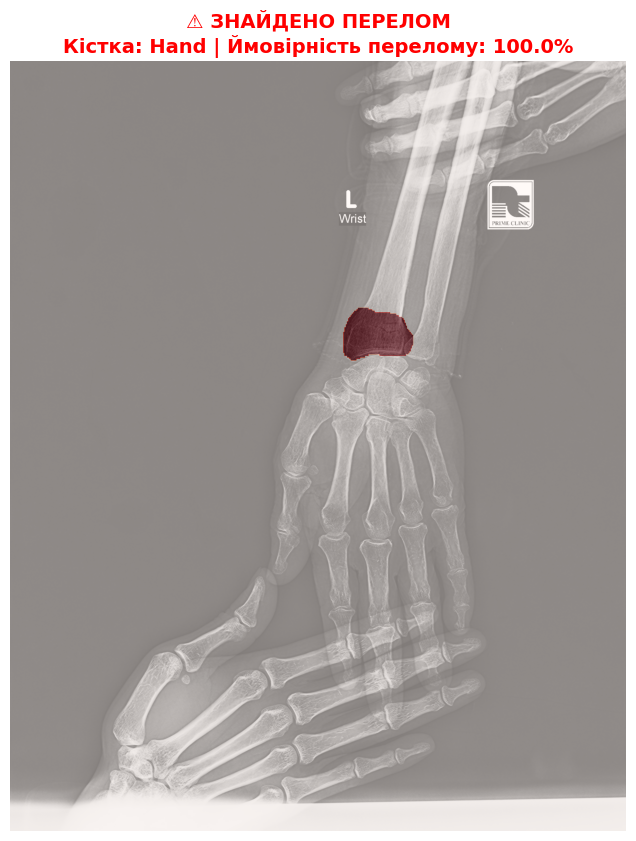

In [38]:
# Визначаємо пристрій
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Завантажуємо класифікатор (працює з розміром 224x224)
print("Завантаження класифікатора...")
classifier = MultiTaskClassifier(num_bone_classes=5).to(device)
# Якщо класифікатор лежить в головній папці, шлях '../multitask_classifier.pth'
classifier.load_state_dict(torch.load('multitask_classifier.pth', map_location=device))
classifier.eval()

# 2. Завантажуємо сегментатор (працює з розміром 512x512)
print("Завантаження сегментатора...")
segmenter = FractureSegmenter(in_channels=3, out_channels=1).to(device)
# Беремо щойно натреновані ваги (вони збереглися в тій же папці, де запущений ноутбук)
segmenter.load_state_dict(torch.load('fracture_segmenter_v5_best.pth', map_location=device))
segmenter.eval()

# Трансформації для інференсу
transform_cls = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

transform_seg = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

bone_classes = ['Hand', 'Leg', 'Hip', 'Shoulder', 'Mixed']

def predict_and_visualize(image_path, threshold=0.5):
    """Каскадний інференс: Класифікатор -> Сегментатор (якщо є перелом)"""

    # Завантаження оригінального зображення
    img = cv2.imread(image_path)
    if img is None:
        print(f"Помилка: не знайдено файл {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_size = img_rgb.shape[:2] # Зберігаємо оригінальні розміри

    # Підготовка тензорів
    tensor_cls = transform_cls(image=img_rgb)['image'].unsqueeze(0).to(device)
    tensor_seg = transform_seg(image=img_rgb)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        # --- ЕТАП 1: Скринінг ---
        logits_bone, logits_fracture = classifier(tensor_cls)
        prob_fracture = torch.sigmoid(logits_fracture).item()

        # Тип кістки: якщо кілька класів > 0.5 -> Mixed, інакше один клас
        probs_bone = torch.sigmoid(logits_bone).squeeze().cpu().numpy()
        individual = [bone_classes[i] for i, p in enumerate(probs_bone)
                      if p > 0.5 and bone_classes[i] != 'Mixed']
        if len(individual) > 1:
            bone_type = f"Mixed ({", ".join(individual)})"
        elif len(individual) == 1:
            bone_type = individual[0]
        else:
            bone_type = bone_classes[int(np.argmax(probs_bone))]

        mask_resized = None
        is_fractured = prob_fracture > threshold

        # --- ЕТАП 2: Деталізація ---
        if is_fractured:
            logits_mask = segmenter(tensor_seg)
            mask_prob = torch.sigmoid(logits_mask).squeeze().cpu().numpy()
            mask_binary = (mask_prob > 0.5).astype(np.uint8)

            # Прибираємо дрібні ізольовані фрагменти (шум моделі)
            # Залишаємо тільки зв'язні компоненти площею > min_area пікселів
            min_area = int(0.001 * mask_binary.shape[0] * mask_binary.shape[1])  # 0.1% площі
            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_binary, connectivity=8)
            clean_mask = np.zeros_like(mask_binary)
            for lbl in range(1, num_labels):  # 0 — фон
                if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
                    clean_mask[labels == lbl] = 1

            # Розтягуємо очищену маску назад до розмірів оригінального знімка
            mask_resized = cv2.resize(clean_mask, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)

    # --- ВІЗУАЛІЗАЦІЯ ---
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    title_info = f"Кістка: {bone_type} | Ймовірність перелому: {prob_fracture:.1%}"

    if is_fractured and mask_resized is not None:
        # Накладаємо червону маску
        plt.imshow(mask_resized, cmap='Reds', alpha=0.5)
        plt.title(f"⚠️ ЗНАЙДЕНО ПЕРЕЛОМ\n{title_info}", color='red', fontsize=14, fontweight='bold')
    else:
        plt.title(f"✅ НОРМА (Без перелому)\n{title_info}", color='green', fontsize=14, fontweight='bold')

    plt.axis('off')
    plt.show()

# ТЕСТУЄМО!
# Вибираємо випадковий знімок з переломом (можеш підставити будь-який інший)
test_image = '../data/FracAtlas/images/Fractured/IMG0000019.jpg'
predict_and_visualize(test_image)